In [1]:
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
from meteostat import Point, Hourly, Stations
from tqdm import tqdm
import sys
import numpy as np
from typing import Optional, Callable, List
# 5 sec: depends a lot on the internet connection
# 30 sec – the south west corner of the black diamond

In [2]:
sys.path.append('Utils/')
from PlotUtils import setMplParam, getColour, getHistoParam, annotate_histogram
# getHistoParam: 
# Nbins, binwidth, bins, counts, bin_centers  = 
# from ExternalFunctions import nice_string_output, add_text_to_ax
setMplParam()

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
# 30 sec
# 

In [4]:
kbh = Point(lat=55.6761, lon=12.5683)

In [ ]:
def get_hourly_example(location: Point, start: datetime, end: datetime ) -> pd.DataFrame: 
    example_df = Hourly(location, start, end) 
    return example_df.fetch()

In [6]:
def isClean(df: pd.DataFrame) -> bool:
    """
    Return True if the DataFrame contains no NaN values.
    If NaNs exist, print each column with its NaN count and return False.
    """
    _is_clean = False
    nan_counts = df.isna().sum()
    nan_columns = nan_counts[nan_counts > 0]
    
    if nan_columns.empty:
        _is_clean = True
    else:
        print("NaN values detected in the following columns:")
        for col, count in nan_columns.items():
            print(f"  → Column: '{col}', NaN count: {count}")

    return _is_clean

In [12]:
example_df = get_hourly_example(kbh, start=datetime(2026, 5, 29), end=datetime(2026, 5, 20))

In [13]:
example_df

,,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
station,time,,,,,,,,,,,


In [39]:
example_df.shape

(6625, 11)

In [40]:
example_df.columns

Index(['temp', 'dwpt', 'rhum', 'prcp', 'snow', 'wdir', 'wspd', 'wpgt', 'pres',
       'tsun', 'coco'],
      dtype='object')

<Axes: title={'center': 'Precipitation (prcp) over Time'}, xlabel='time'>

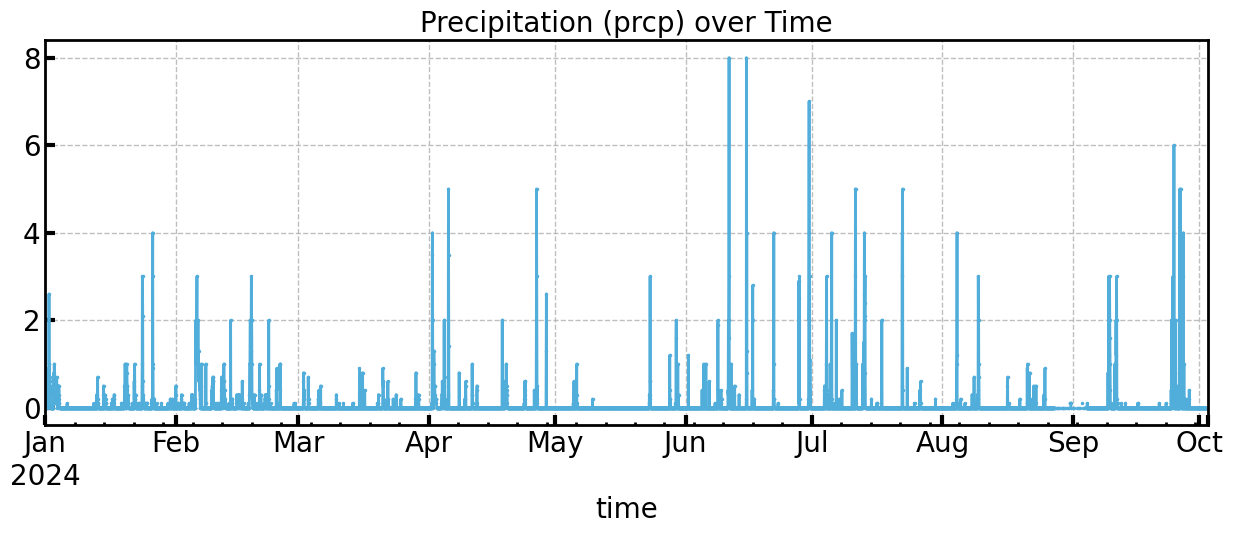

In [41]:
example_df['prcp'].plot(figsize=(15,5), title='Precipitation (prcp) over Time')

<Axes: title={'center': 'Transformed Precipitation (prcp) over Time'}, xlabel='time'>

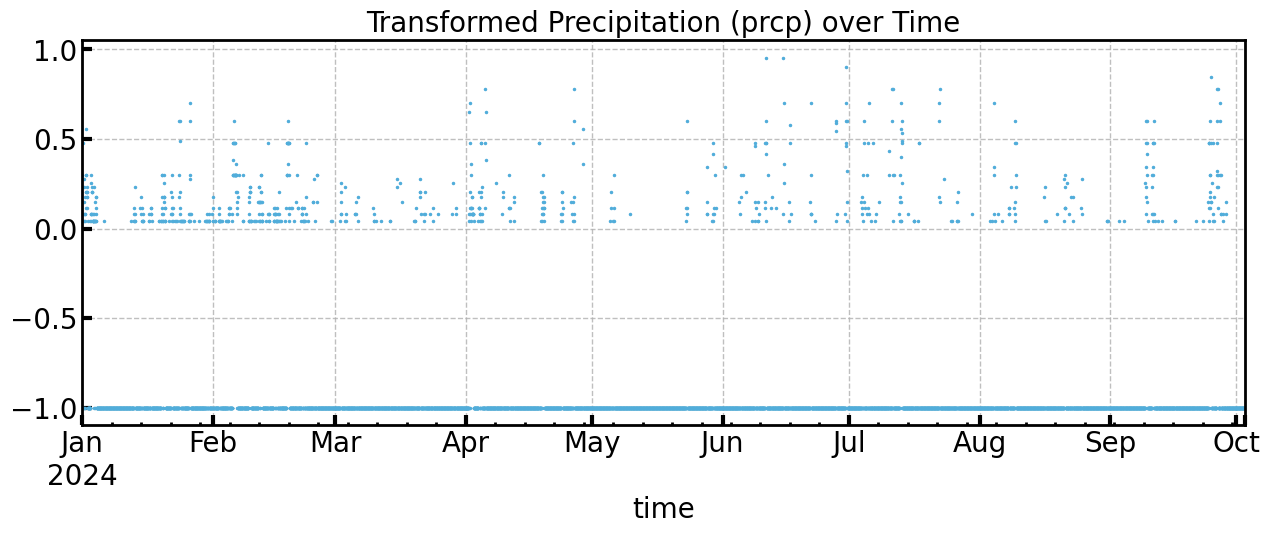

In [42]:
example_df['prcp_filled'] = example_df['prcp'].fillna(0)
example_df['prcp_t'] = np.where(
    example_df['prcp_filled'] > 0,
    np.log10(example_df['prcp_filled'] + 1),
    -1
)


example_df['prcp_t'].plot(figsize=(15,5), title='Transformed Precipitation (prcp) over Time', linestyle='None')

<Axes: title={'center': 'Wind Speed (wspd) over Time'}, xlabel='time'>

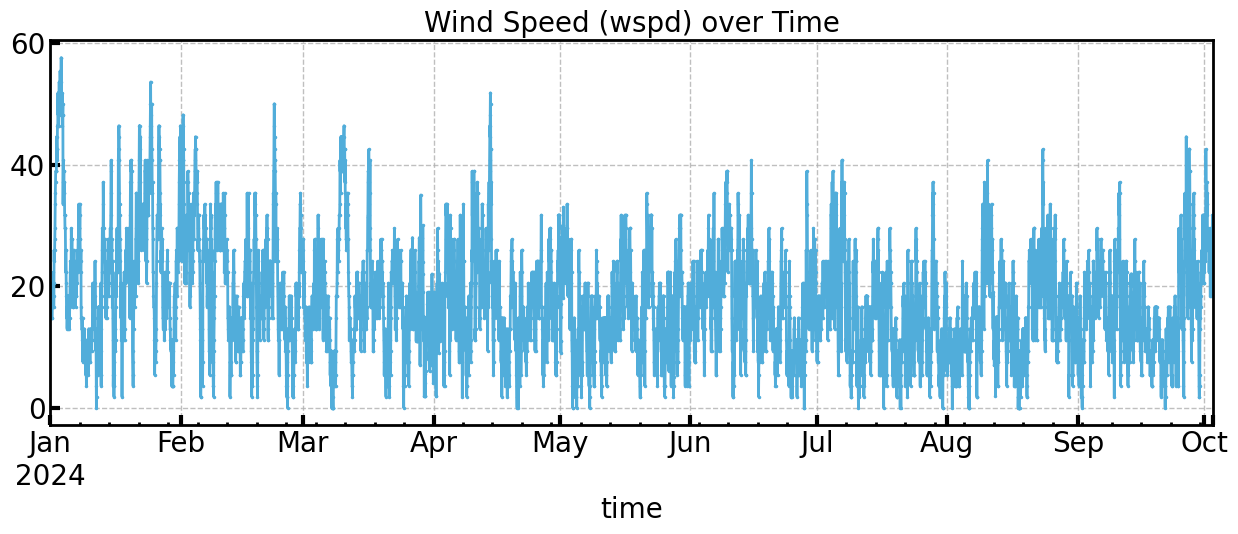

In [43]:
example_df['wspd'].plot(figsize=(15,5), title='Wind Speed (wspd) over Time')

<Axes: title={'center': 'Transformed Wind Speed (wspd) over Time'}, xlabel='time'>

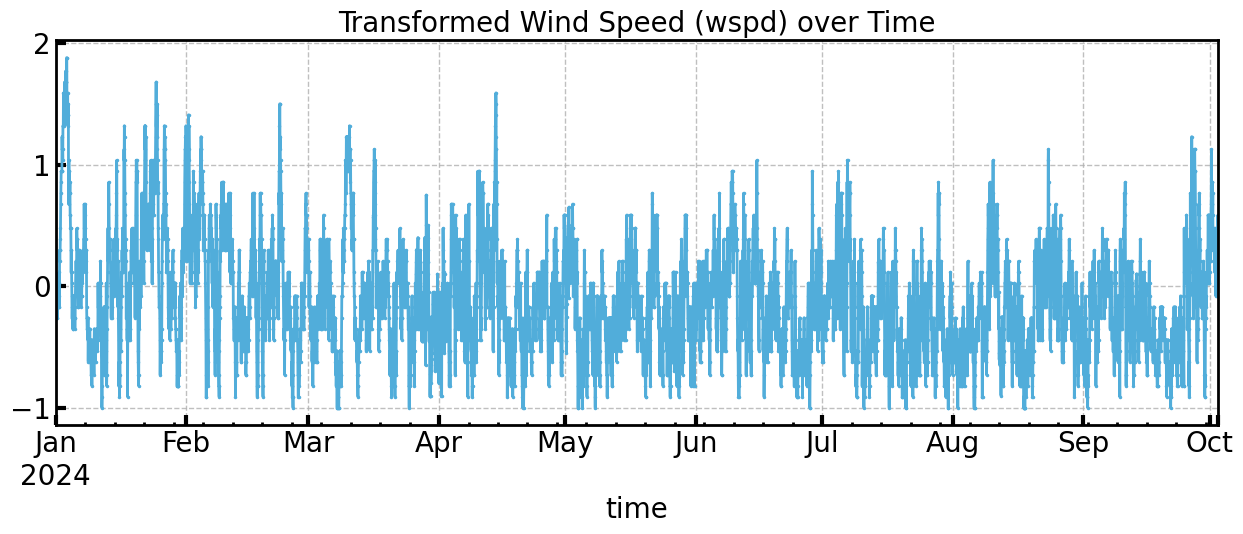

In [44]:
example_df['wspd_t']= (example_df['wspd']-20)/20
example_df['wspd_t'].plot(figsize=(15,5), title='Transformed Wind Speed (wspd) over Time')

<Axes: title={'center': 'Wind Gust Speed (wpgt) over Time'}, xlabel='time'>

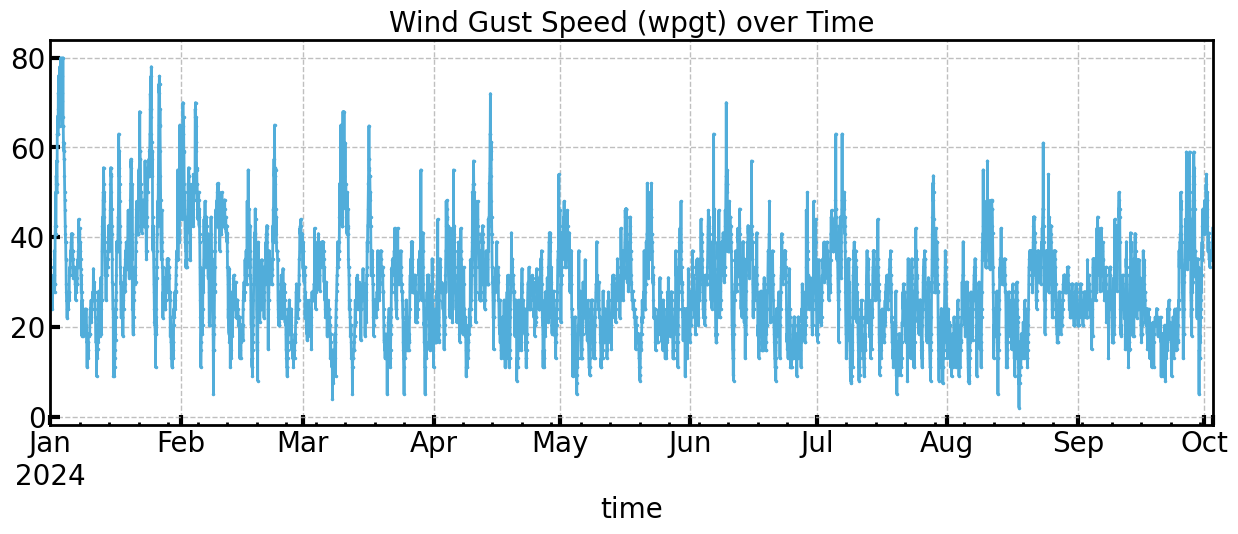

In [45]:
example_df['wpgt'].plot(figsize=(15,5), title='Wind Gust Speed (wpgt) over Time')

<Axes: title={'center': 'Transformed Wind Gust Speed (wpgt) over Time'}, xlabel='time'>

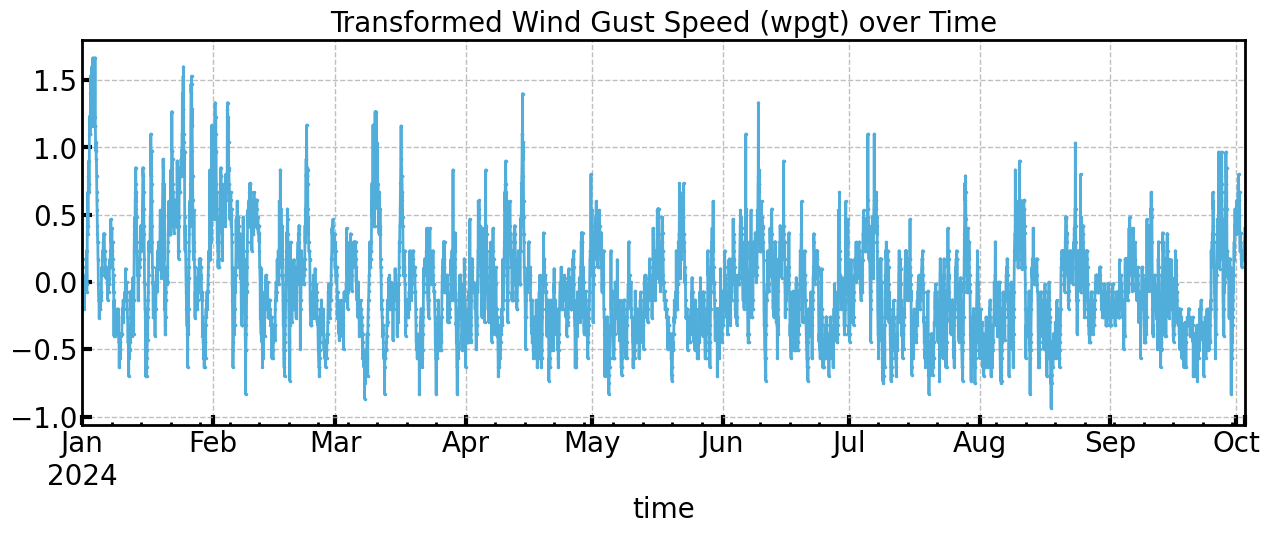

In [46]:
example_df['wpgt_t']= (example_df['wpgt']-30)/30
example_df['wpgt_t'].plot(figsize=(15,5), title='Transformed Wind Gust Speed (wpgt) over Time')

In [47]:
isClean(example_df)

NaN values detected in the following columns:
  → Column: 'prcp', NaN count: 154
  → Column: 'snow', NaN count: 6625
  → Column: 'tsun', NaN count: 6625


False

In [48]:
# from example_df only selct these: ['temp', 'dwpt', 'rhum', 'prcp', 'wdir', 'wspd', 'wpgt', 'pres','tsun']
# 'tsun', 'snow', 'prcp' has nans
example_df = example_df[['temp', 'dwpt', 'rhum', 'prcp', 'wdir', 'wspd', 'wpgt', 'pres']]

In [49]:
class CyclicConversion:
    """
    Convert time- and angle-based features into cyclic (sin/cos) representations
    to preserve their periodic nature.

    Example:
        23:00 and 01:00 are numerically far apart but cyclically close.
        Using sin/cos encodings helps the model learn continuity across cycles.

    Parameters
    ----------
    add_time : bool, optional
        If True, adds cyclic encodings for hour, weekday, and day-of-year.
    add_angle : bool, optional
        If True, replaces 'wdir' (wind direction, degrees) with sin/cos encoding.
    """

    def __init__(self, add_time=True, add_angle=True):
        self.add_time = add_time
        self.add_angle = add_angle

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Apply cyclic feature transformations on the given DataFrame.

        Parameters
        ----------
        df : pd.DataFrame
            Input DataFrame with a DatetimeIndex (for temporal encoding)
            and optionally a 'wdir' column (for angular encoding).

        Returns
        -------
        pd.DataFrame
            DataFrame with new sin/cos features and removed raw cyclic columns.
        """
        df = df.copy()

        # --- Temporal encoding ---
        if self.add_time:
            # Extract temporal components from index
            df['hour'] = df.index.hour
            df['dayofweek'] = df.index.dayofweek
            df['dayofyear'] = df.index.dayofyear

            # Encode each as sine/cosine pairs to preserve cyclic continuity
            df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
            df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)
            df['sin_week'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
            df['cos_week'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
            df['sin_year'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
            df['cos_year'] = np.cos(2 * np.pi * df['dayofyear'] / 365)

            # Drop raw integer-based time features (not cyclically meaningful)
            df = df.drop(columns=['hour', 'dayofweek', 'dayofyear'], errors='ignore')

        # --- Angular encoding (wind direction) ---
        if self.add_angle and 'wdir' in df.columns:
            # Convert wind direction (°) to unit circle representation
            df['sin_wdir'] = np.sin(2 * np.pi * df['wdir'] / 360)
            df['cos_wdir'] = np.cos(2 * np.pi * df['wdir'] / 360)
            df = df.drop(columns=['wdir'], errors='ignore')

        return df


In [50]:
class PseudoNormaliser:
    """
    Lightweight fixed-constant normaliser.
    Scales meteorological features to approximately [-1, 1]
    using predefined constants.

    Features are grouped by normalisation type:
      - scale–shift: linear transform  (x - shift) / scale
      - log: nonlinear transform  log(x + log_offset) with replacement for zeros

    This avoids dataset-specific fitting and ensures consistent scaling
    across datasets.
    """

    def __init__(self):
        # --- Linear (scale–shift) features ---
        # Each tuple: (shift, scale)
        self.scale_shift = {
            # temperature-related (°C)
            'temp': (15.0, 20.0),   # roughly [-5, +35]
            'dwpt': (0.0, 20.0),
            # relative humidity (%)
            'rhum': (50.0, 50.0),   # [0, 100]
            # snow (mm)
            'snow': (0.0, 50.0),    # mostly 0; rare spikes
            # wind (km/h)
            'wspd': (20.0, 20.0),   # [0, 40]
            'wpgt': (30.0, 30.0),   # [0, 60]
            # pressure (hPa)
            'pres': (1013.0, 30.0), # [980, 1040]
            # sunshine (minutes)
            'tsun': (30.0, 30.0),   # [0, 60]
        }

        # --- Log-transformed features ---
        # Each tuple: (log_offset, zero_replacement)
        #   log_offset → value added before log
        #   zero_replacement → used when raw value == 0
        self.log_transform = {
            'prcp': (1.0, -1.0),  # log10(x + 1), replace 0 with -1
        }

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        # --- Exclude NaNs from processing but keep their positions ---
        nan_mask = df.isna()

        # --- Apply linear transforms ---
        for col, (shift, scale) in self.scale_shift.items():
            if col in df.columns:
                df[col] = (df[col] - shift) / scale

        # --- Apply log transforms ---
        for col, (log_offset, zero_value) in self.log_transform.items():
            if col in df.columns:
                coldata = df[col]
                transformed = pd.Series(np.nan, index=coldata.index, dtype=float)
                transformed[coldata > 0] = np.log10(coldata[coldata > 0] + log_offset)
                transformed[coldata == 0] = zero_value
                df[col] = transformed

        # --- Restore NaNs explicitly ---
        df[nan_mask] = np.nan

        # Do NOT fill NaNs — they’ll be handled later through masking
        return df

In [51]:
class CategoricalEncoder:
    """
    Encode categorical weather condition feature ('coco') using either:
      - one-hot encoding (dense numerical expansion), or
      - embedding indices (integer codes suitable for learnable embeddings).

    Parameters
    ----------
    column : str, optional
        Name of the categorical column to encode (default: 'coco').
    method : {'onehot', 'embedding'}, optional
        Encoding strategy.
    num_classes : int, optional
        Number of unique classes (default: 27 for Meteostat weather codes).

    Notes
    -----
    - One-hot encoding expands the column into multiple binary features.
    - Embedding mode keeps a single integer feature in range [0, num_classes-1].
      The integer can be later mapped to a learnable embedding matrix in the model.
    """

    def __init__(self, column='coco', method='embedding', num_classes=27):
        self.column = column
        self.method = method
        self.num_classes = num_classes

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Apply categorical encoding transformation.

        Parameters
        ----------
        df : pd.DataFrame
            Input DataFrame containing the categorical feature.

        Returns
        -------
        pd.DataFrame
            DataFrame with the categorical column transformed according to the selected method.
        """
        df = df.copy()

        # Skip if the specified column is not found
        if self.column not in df.columns:
            return df

        # --- One-hot encoding ---
        if self.method == 'onehot':
            one_hot = pd.get_dummies(
                df[self.column].astype(int),
                prefix=self.column,
                columns=[self.column],
                drop_first=False
            )
            df = df.drop(columns=[self.column])
            df = pd.concat([df, one_hot], axis=1)

        # --- Embedding encoding ---
        elif self.method == 'embedding':
            # Fill missing values and convert to integer IDs
            df[self.column] = df[self.column].astype('Int64')  # nullable integer type
            # df[self.column] = df[self.column].fillna(0).astype(int)
            # Clip to valid index range for embedding layer (0–num_classes−1)
            # df[self.column] = df[self.column].clip(0, self.num_classes - 1)
            df[self.column] = df[self.column].mask(
            df[self.column].notna(),
            df[self.column].clip(0, self.num_classes - 1)
        )


        # --- Invalid method ---
        else:
            raise ValueError("method must be either 'onehot' or 'embedding'")

        return df

In [52]:
class MeteoPreprocessor:
    """
    Composes cyclic, categorical, and pseudo-normalisation transformations.
    Accepts either pandas.DataFrame (preferred) or numpy.ndarray input.
    """

    def __init__(self,
                 use_cyclic: bool = True,
                 categorical_mode: str = 'embedding'):
        self.use_cyclic = use_cyclic
        self.cyclic = CyclicConversion() if use_cyclic else None
        self.encoder = CategoricalEncoder(method=categorical_mode)
        self.scaler = PseudoNormaliser()

    def transform(self, data):
        """Apply transformations, supporting both pandas and numpy input."""
        if isinstance(data, pd.DataFrame):
            df = data.copy()
            if self.cyclic:
                df = self.cyclic.transform(df)
            df = self.encoder.transform(df)
            df = self.scaler.transform(df)
            return df

        elif isinstance(data, np.ndarray):
            # Only apply numeric scaling on numpy arrays (fast path)
            return self._transform_numpy(data)

        else:
            raise TypeError("Input must be pandas.DataFrame or numpy.ndarray")

    def _transform_numpy(self, arr: np.ndarray) -> np.ndarray:
        """Fast-path numeric-only transformation for numpy arrays."""
        # Example: apply fixed scaling assuming same column order as training
        # For simplicity, use global constants from PseudoNormaliser
        arr = arr.copy()
        # You can implement constant-based scaling here
        return arr

    def __call__(self, data):
        return self.transform(data)


In [53]:
class MeteoDataset(Dataset):
    """
    Dataset for meteorological sequence-to-sequence forecasting.
    Robust to missing or all-NaN feature columns.

    Each sample consists of:
        - X: input window of shape (window_size, num_features)
        - Y: target window of shape (horizon, num_features)
    """

    def __init__(self,
                 source_data: pd.DataFrame,
                 feature_cols: List[str],
                 window_size: int = 24,
                 horizon: int = 6,
                 overlap: bool = True,
                 strict: bool = False):  # relaxed default
        self.feature_cols = feature_cols
        self.window_size = window_size
        self.horizon = horizon
        self.overlap = overlap
        self.strict = strict

        # --- Defensive copy ---
        self.source_data = source_data.copy()

        # --- Drop obvious metadata columns ---
        for col in ['station', 'time']:
            if col in self.source_data.columns:
                self.source_data = self.source_data.drop(columns=[col])

        # --- Convert nullable pandas dtypes → native float ---
        self.source_data = self.source_data.convert_dtypes()
        for col in self.source_data.columns:
            if pd.api.types.is_extension_array_dtype(self.source_data[col].dtype):
                self.source_data[col] = self.source_data[col].astype(float)

        # --- Identify usable columns ---
        self.available_features = self._validate_features()

        # --- Subset to usable columns ---
        self.source_data = self.source_data[self.available_features]

        # --- Convert to NumPy float32 array ---
        self.values = self.source_data.values.astype(np.float32)

        # --- Build sliding windows ---
        self.windows = self._make_windows()

    # ==============================================================
    def _validate_features(self) -> List[str]:
        """Check available columns and drop missing / all-NaN ones."""
        missing = [c for c in self.feature_cols if c not in self.source_data.columns]
        all_nan = [c for c in self.feature_cols
                   if c in self.source_data.columns and self.source_data[c].isna().all()]

        available = [c for c in self.feature_cols
                     if c in self.source_data.columns and c not in all_nan]

        if missing:
            print(f"⚠️ Missing columns ignored: {missing}")
        if all_nan:
            print(f"⚠️ Columns all NaN dropped: {all_nan}")
        if not available:
            raise ValueError("No valid feature columns remain after filtering.")

        return available

    # ==============================================================
    def _make_windows(self):
        """Construct (X, Y) window pairs."""
        X, Y = [], []
        step = 1 if self.overlap else self.window_size
        n = len(self.values)
        for i in range(0, n - self.window_size - self.horizon + 1, step):
            x = self.values[i : i + self.window_size]
            y = self.values[i + self.window_size : i + self.window_size + self.horizon]
            X.append(x)
            Y.append(y)
        return list(zip(X, Y))

    # ==============================================================
    def __len__(self):
        return len(self.windows)

    # def __getitem__(self, idx):
    #     x, y = self.windows[idx]
    #     return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)
    def __getitem__(self, idx):
        x, y = self.windows[idx]
        x_tensor = torch.tensor(x, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.float32)

        # Create masks: True where data is valid
        x_mask = ~torch.isnan(x_tensor)
        y_mask = ~torch.isnan(y_tensor)

        # Optionally replace NaNs with zeros for numerical stability
        x_tensor = torch.nan_to_num(x_tensor, nan=0.0)
        y_tensor = torch.nan_to_num(y_tensor, nan=0.0)

        return x_tensor, y_tensor, x_mask, y_mask



In [54]:
processed_df = MeteoPreprocessor()(example_df)
feature_list = processed_df.columns.tolist()  # after transformation

In [55]:
feature_list

['temp',
 'dwpt',
 'rhum',
 'prcp',
 'wspd',
 'wpgt',
 'pres',
 'sin_hour',
 'cos_hour',
 'sin_week',
 'cos_week',
 'sin_year',
 'cos_year',
 'sin_wdir',
 'cos_wdir']

In [56]:
example_dataset = MeteoDataset(
    source_data=processed_df,
    feature_cols=feature_list,
    window_size=48,
    horizon=24,
    overlap=True
)

# station should be removed

In [57]:
example_dataset.__len__()

6554

In [58]:
len(example_dataset)

6554

In [59]:
%%time
for _ in example_dataset:
    pass

CPU times: user 2.75 s, sys: 72.5 ms, total: 2.82 s
Wall time: 3.83 s


In [60]:
def plot_feature_distributions(dataset):
    """
    Plot histograms showing the distribution of each feature across sampled windows.
    Works even when PyTorch lacks NumPy support.
    """
    assert hasattr(dataset, "feature_cols"), "Dataset must have 'feature_cols' attribute."
    assert len(dataset) > 0, "Dataset is empty."
    num_samples: int = 10

    indices = np.random.choice(len(dataset), size=min(num_samples, len(dataset)), replace=False)

    # Stack all X tensors from sampled windows (universal conversion)
    X_samples = []
    for idx in indices:
        x, _, _, _= dataset[idx]
        try:
            arr = x.detach().cpu().to(torch.float32).numpy()
        except RuntimeError:
            # Fallback if numpy bridge is unavailable
            arr = np.array(x.detach().cpu().to(torch.float32).tolist(), dtype=np.float32)
        X_samples.append(arr)

    X_samples = np.stack(X_samples)  # (num_samples, window_size, num_features)
    flat_values = X_samples.reshape(-1, X_samples.shape[-1])

    num_features = len(dataset.feature_cols)
    ncols = 3
    nrows = int(np.ceil(num_features / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(10*ncols, 6*nrows))
    axes = axes.flatten()

    for i, feature in enumerate(dataset.feature_cols):
        ax = axes[i]
        ax.hist(flat_values[:, i], bins=15, edgecolor='black', color='skyblue')
        ax.set_xlabel(feature, fontsize=28) 
        ax.set_ylabel('#/bin', fontsize=28)
        annotate_histogram(ax, fontsize=20)
        # print the total count
        ax.text(0.95, 0.90, f'Total: {flat_values.shape[0]}',
                horizontalalignment='right',
                verticalalignment='top',
                transform=ax.transAxes,
                fontsize=20)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


In [61]:
import torch
x, y, x_mask, y_mask = example_dataset[0]
print("NaN count in x:", torch.isnan(x).sum().item())
print("Mask false count:", (~x_mask).sum().item())


NaN count in x: 0
Mask false count: 0


In [ ]:
plot_feature_distributions(example_dataset)
#  sec
